In [9]:
!pip install imgaug
!pip install mlxtend


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:

import os
import glob
import h5py
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mimg
import imgaug.augmenters as iaa
from os.path import join, exists
from PIL import Image
from pathlib import Path
from skimage.io import imread
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, Flatten, SeparableConv2D, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
import cv2

# If using Jupyter Notebook
# %matplotlib inline  


In [11]:
import os
import numpy as np
import tensorflow as tf
import imgaug

# Set the seed for hash-based operations
os.environ['PYTHONHASHSEED'] = '0'

# Set NumPy seed
np.random.seed(111)

# Set TensorFlow seed
tf.random.set_seed(111)

# Set imgaug seed
imgaug.random.seed(111)


In [12]:
# Define path to the data directory
data_dir = Path('chest_xray')

# Path to train directory (Fancy pathlib...no more os.path!!)
train_dir = data_dir / 'train'

# Path to validation directory
val_dir = data_dir / 'val'

# Path to test directory
test_dir = data_dir / 'test'

In [13]:
# Get the path to the normal and pneumonia sub-directories
normal_cases_dir = train_dir / 'NORMAL'
pneumonia_cases_dir = train_dir / 'PNEUMONIA'

# Get the list of all the images
normal_cases = normal_cases_dir.glob('*.jpeg')
pneumonia_cases = pneumonia_cases_dir.glob('*.jpeg')

# An empty list. We will insert the data into this list in (img_path, label) format
train_data = []

# Go through all the normal cases. The label for these cases will be 0
for img in normal_cases:
    train_data.append((img,0))

# Go through all the pneumonia cases. The label for these cases will be 1
for img in pneumonia_cases:
    train_data.append((img, 1))

# Get a pandas dataframe from the data we have in our list 
train_data = pd.DataFrame(train_data, columns=['image', 'label'],index=None)

# Shuffle the data 
train_data = train_data.sample(frac=1.).reset_index(drop=True)

# How the dataframe looks like?
train_data.head()

,image,label
0,chest_xray\train\PNEUMONIA\BACTERIA-8597098-00...,1
1,chest_xray\train\PNEUMONIA\BACTERIA-1620679-00...,1
2,chest_xray\train\PNEUMONIA\BACTERIA-5028760-00...,1
3,chest_xray\train\PNEUMONIA\BACTERIA-1083680-00...,1
4,chest_xray\train\PNEUMONIA\VIRUS-8133734-0002....,1


label
1    3881
0    1348
Name: count, dtype: int64


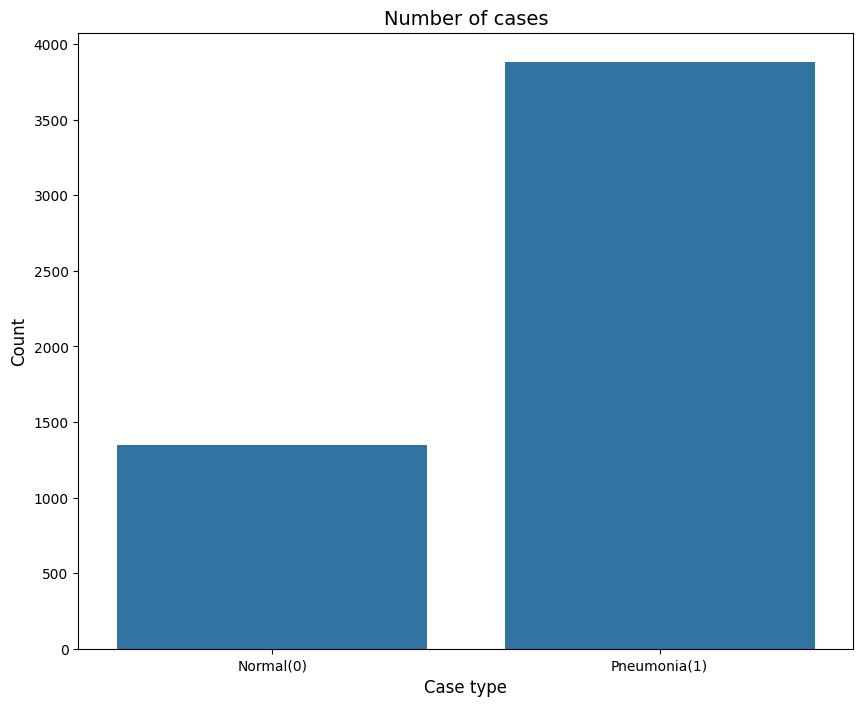

In [14]:
cases_count = train_data['label'].value_counts()
print(cases_count)

# Plot the results 
plt.figure(figsize=(10,8))
sns.barplot(x=cases_count.index, y= cases_count.values)
plt.title('Number of cases', fontsize=14)
plt.xlabel('Case type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(range(len(cases_count.index)), ['Normal(0)', 'Pneumonia(1)'])
plt.show()

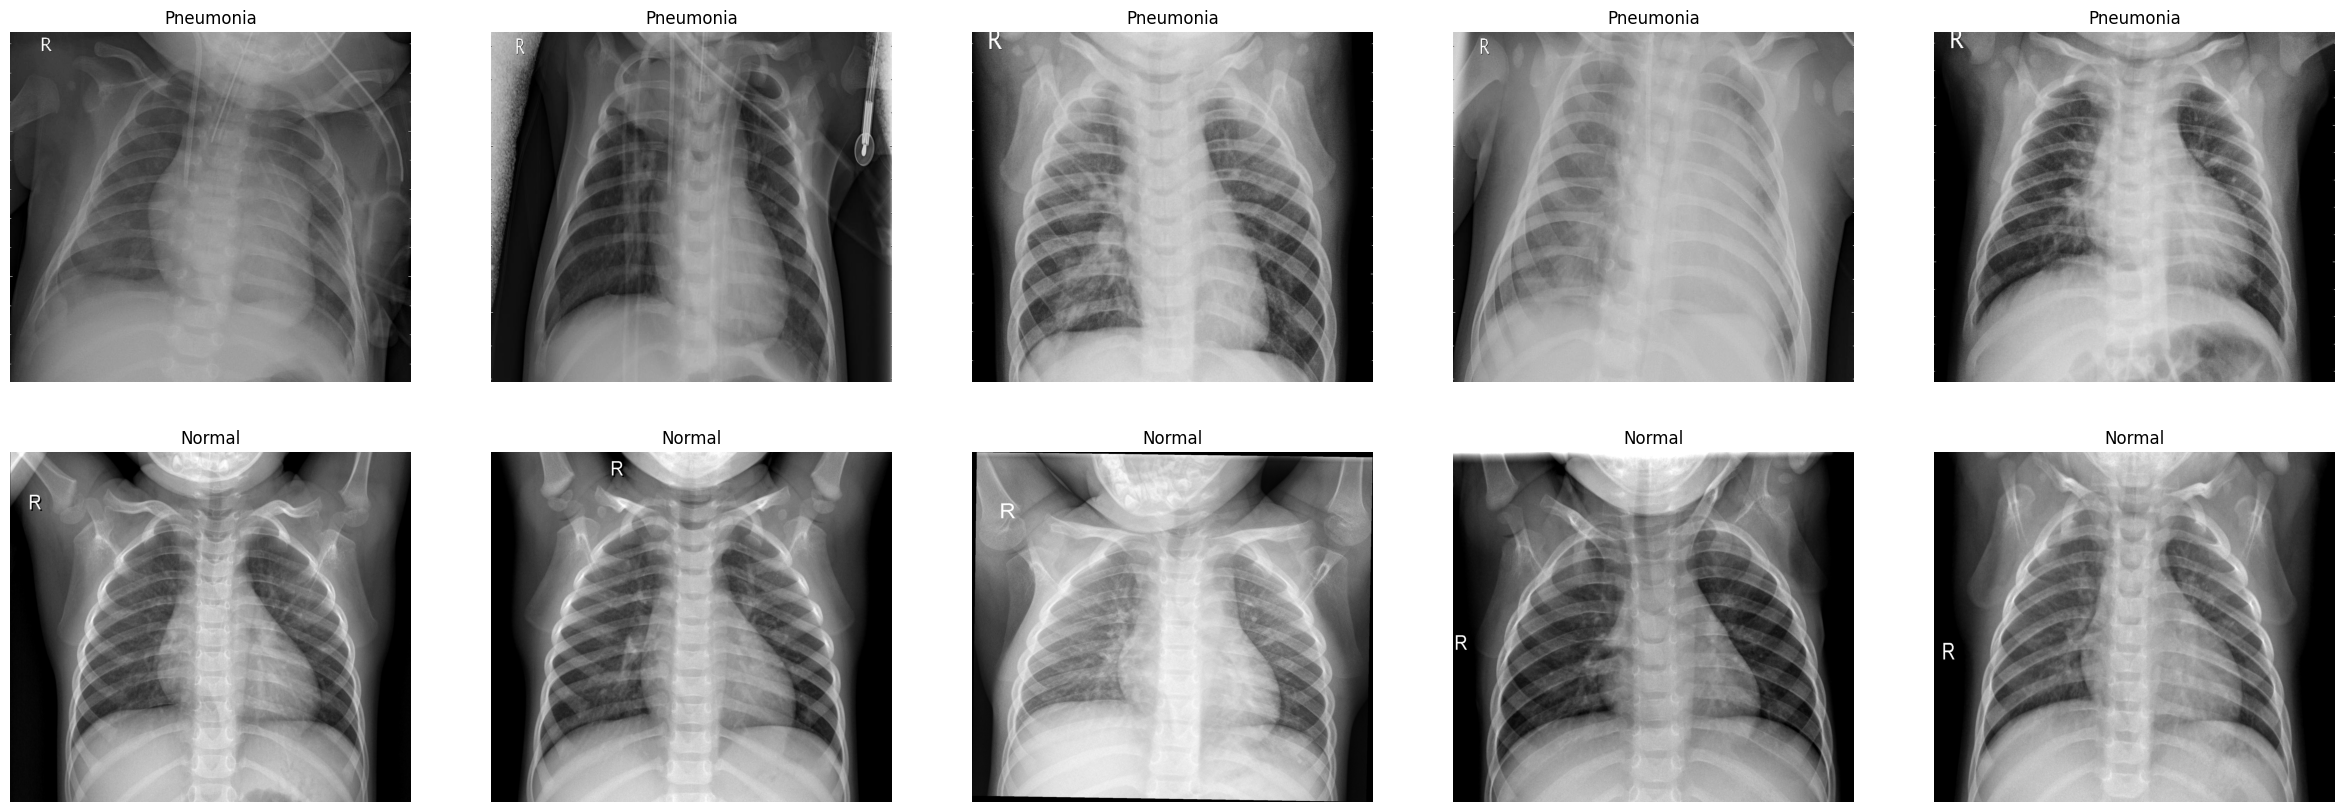

In [15]:
# Get few samples for both the classes
pneumonia_samples = (train_data[train_data['label']==1]['image'].iloc[:5]).tolist()
normal_samples = (train_data[train_data['label']==0]['image'].iloc[:5]).tolist()

# Concat the data in a single list and del the above two list
samples = pneumonia_samples + normal_samples
del pneumonia_samples, normal_samples

# Plot the data 
f, ax = plt.subplots(2,5, figsize=(30,10))
for i in range(10):
    img = imread(samples[i])
    ax[i//5, i%5].imshow(img, cmap='gray')
    if i<5:
        ax[i//5, i%5].set_title("Pneumonia")
    else:
        ax[i//5, i%5].set_title("Normal")
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_aspect('auto')
plt.show()

In [16]:
# Get the path to the sub-directories
normal_cases_dir = val_dir / 'NORMAL'
pneumonia_cases_dir = val_dir / 'PNEUMONIA'

# Get the list of all the images
normal_cases = normal_cases_dir.glob('*.jpeg')
pneumonia_cases = pneumonia_cases_dir.glob('*.jpeg')

# List that are going to contain validation images data and the corresponding labels
valid_data = []
valid_labels = []


# Some images are in grayscale while majority of them contains 3 channels. So, if the image is grayscale, we will convert into a image with 3 channels.
# We will normalize the pixel values and resizing all the images to 224x224 

# Normal cases
for img in normal_cases:
    img = cv2.imread(str(img))
    img = cv2.resize(img, (224,224))
    if img.shape[2] ==1:
        img = np.dstack([img, img, img])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32)/255.
    label = to_categorical(0, num_classes=2)
    valid_data.append(img)
    valid_labels.append(label)
                      
# Pneumonia cases        
for img in pneumonia_cases:
    img = cv2.imread(str(img))
    img = cv2.resize(img, (224,224))
    if img.shape[2] ==1:
        img = np.dstack([img, img, img])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32)/255.
    label = to_categorical(1, num_classes=2)
    valid_data.append(img)
    valid_labels.append(label)
    
# Convert the list into numpy arrays
valid_data = np.array(valid_data)
valid_labels = np.array(valid_labels)

print("Total number of validation examples: ", valid_data.shape)
print("Total number of labels:", valid_labels.shape)

Total number of validation examples:  (490, 224, 224, 3)
Total number of labels: (490, 2)


In [17]:
print(os.listdir(normal_cases_dir))
print(os.listdir(pneumonia_cases_dir))


['NORMAL-1110860-0001.jpeg', 'NORMAL-11419-0001.jpeg', 'NORMAL-115218-0001.jpeg', 'NORMAL-1160949-0001.jpeg', 'NORMAL-1228182-0001.jpeg', 'NORMAL-1283091-0001.jpeg', 'NORMAL-1318320-0001.jpeg', 'NORMAL-1368583-0001.jpeg', 'NORMAL-1430636-0001.jpeg', 'NORMAL-1520670-0001.jpeg', 'NORMAL-152130-0001.jpeg', 'NORMAL-159472-0001.jpeg', 'NORMAL-1608079-0001.jpeg', 'NORMAL-1698651-0001.jpeg', 'NORMAL-171327-0001.jpeg', 'NORMAL-1759114-0001.jpeg', 'NORMAL-1763721-0001.jpeg', 'NORMAL-1771524-0001.jpeg', 'NORMAL-1803887-0001.jpeg', 'NORMAL-1858497-0001.jpeg', 'NORMAL-186900-0001.jpeg', 'NORMAL-1931427-0001.jpeg', 'NORMAL-1944537-0001.jpeg', 'NORMAL-2107985-0001.jpeg', 'NORMAL-2123652-0001.jpeg', 'NORMAL-2162145-0001.jpeg', 'NORMAL-217318-0001.jpeg', 'NORMAL-2233350-0001.jpeg', 'NORMAL-2274324-0001.jpeg', 'NORMAL-2280080-0001.jpeg', 'NORMAL-2298727-0001.jpeg', 'NORMAL-2403676-0001.jpeg', 'NORMAL-2477476-0001.jpeg', 'NORMAL-2514572-0001.jpeg', 'NORMAL-2578531-0001.jpeg', 'NORMAL-2704875-0001.jpeg',

In [18]:
import imgaug.augmenters as iaa

# Augmentation sequence
seq = iaa.OneOf([
    iaa.Fliplr(0.5),  # 50% chance to flip horizontally
    iaa.Affine(rotate=(-20, 20)),  # Random rotation between -20 and 20 degrees
    iaa.Multiply((0.8, 1.2))  # Adjust brightness (darken or lighten)
])


In [19]:
def data_gen(data, batch_size):
    # Get total number of samples in the data
    n = len(data)
    steps = n//batch_size
    
    # Define two numpy arrays for containing batch data and labels
    batch_data = np.zeros((batch_size, 224, 224, 3), dtype=np.float32)
    batch_labels = np.zeros((batch_size,2), dtype=np.float32)

    # Get a numpy array of all the indices of the input data
    indices = np.arange(n)
    
    # Initialize a counter
    i =0
    while True:
        np.random.shuffle(indices)
        # Get the next batch 
        count = 0
        next_batch = indices[(i*batch_size):(i+1)*batch_size]
        for j, idx in enumerate(next_batch):
            img_name = data.iloc[idx]['image']
            label = data.iloc[idx]['label']
            
            # one hot encoding
            encoded_label = to_categorical(label, num_classes=2)
            # read the image and resize
            img = cv2.imread(str(img_name))
            img = cv2.resize(img, (224,224))
            
            # check if it's grayscale
            if img.shape[2]==1:
                img = np.dstack([img, img, img])
            
            # cv2 reads in BGR mode by default
            orig_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # normalize the image pixels
            orig_img = img.astype(np.float32)/255.
            
            batch_data[count] = orig_img
            batch_labels[count] = encoded_label
            
            # generating more samples of the undersampled class
            if label==0 and count < batch_size-2:
                aug_img1 = seq.augment_image(img)
                aug_img2 = seq.augment_image(img)
                aug_img1 = cv2.cvtColor(aug_img1, cv2.COLOR_BGR2RGB)
                aug_img2 = cv2.cvtColor(aug_img2, cv2.COLOR_BGR2RGB)
                aug_img1 = aug_img1.astype(np.float32)/255.
                aug_img2 = aug_img2.astype(np.float32)/255.

                batch_data[count+1] = aug_img1
                batch_labels[count+1] = encoded_label
                batch_data[count+2] = aug_img2
                batch_labels[count+2] = encoded_label
                count +=2
            
            else:
                count+=1
            
            if count==batch_size-1:
                break
            
        i+=1
        yield batch_data, batch_labels
            
        if i>=steps:
            i=0

In [20]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, SeparableConv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_lung_model():
    input_img = Input(shape=(224,224,3), name='LungImageInput')
    
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='Lung_Conv1_1')(input_img)
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='Lung_Conv1_2')(x)
    x = MaxPooling2D((2,2), name='Lung_pool1')(x)

    x = SeparableConv2D(128, (3,3), activation='relu', padding='same', name='Lung_Conv2_1')(x)
    x = SeparableConv2D(128, (3,3), activation='relu', padding='same', name='Lung_Conv2_2')(x)
    x = MaxPooling2D((2,2), name='Lung_pool2')(x)

    x = SeparableConv2D(256, (3,3), activation='relu', padding='same', name='Lung_Conv3_1')(x)
    x = BatchNormalization(name='Lung_bn1')(x)
    x = SeparableConv2D(256, (3,3), activation='relu', padding='same', name='Lung_Conv3_2')(x)
    x = BatchNormalization(name='Lung_bn2')(x)
    x = MaxPooling2D((2,2), name='Lung_pool3')(x)

    x = Flatten(name='Lung_flatten')(x)
    x = Dense(512, activation='relu', name='Lung_fc1')(x)
    x = Dropout(0.5, name='Lung_dropout1')(x)
    x = Dense(2, activation='softmax', name='Lung_Output')(x)

    model = Model(inputs=input_img, outputs=x)
    return model

# Build and compile the model
lung_model = build_lung_model()
lung_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
lung_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ LungImageInput (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_Conv1_1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_Conv1_2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_pool1 (MaxPooling2D)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_Conv2_1 (SeparableConv2D)       │ (None, 112, 112, 128)       │           8,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_Conv2_2 (SeparableConv2D)       │ (None, 112, 112, 128)       │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_pool2 (MaxPooling2D)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_Conv3_1 (SeparableConv2D)       │ (None, 56, 56, 256)         │          34,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_bn1 (BatchNormalization)        │ (None, 56, 56, 256)         │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_Conv3_2 (SeparableConv2D)       │ (None, 56, 56, 256)         │          68,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_bn2 (BatchNormalization)        │ (None, 56, 56, 256)         │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_pool3 (MaxPooling2D)            │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_flatten (Flatten)               │ (None, 200704)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_fc1 (Dense)                     │ (None, 512)                 │     102,760,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_dropout1 (Dropout)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Lung_Output (Dense)                  │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 102,931,586 (392.65 MB)

 Trainable params: 102,930,562 (392.65 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [21]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten

# Load VGG16 model with pretrained ImageNet weights
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom layers on top
x = Flatten()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(2, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1024)                │      25,691,136 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 40,931,650 (156.14 MB)

 Trainable params: 26,216,962 (100.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
import os
print(os.listdir("chest_xray"))

['.ipynb_checkpoints', 'test', 'train', 'val']


In [23]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define optimizer
opt = Adam(learning_rate=0.0001, decay=1e-5)

# Define callbacks
es = EarlyStopping(patience=5, restore_best_weights=True)  # Stops early & restores best weights
chkpt = ModelCheckpoint(filepath='best_model_todate.weights.h5', save_best_only=True, save_weights_only=True)  # FIXED: Added `.weights.h5`

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])


C:\Users\A\AppData\Roaming\Python\Python312\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [24]:
batch_size = 16
nb_epochs = 20

# Get a train data generator
train_data_gen = data_gen(data=train_data, batch_size=batch_size)

# Define the number of training steps
nb_train_steps = train_data.shape[0]//batch_size

print("Number of training and validation steps: {} and {}".format(nb_train_steps, len(valid_data)))

Number of training and validation steps: 326 and 490


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)
train_data_gen = datagen.flow_from_directory(
    "chest_xray/train",  # Make sure this path is correct
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print(f"Found {train_data_gen.n} images in {train_data_gen.directory}")


Found 5229 images belonging to 2 classes.
Found 5229 images in chest_xray/train


In [27]:
batch = next(iter(train_data_gen))  # Get one batch
print(len(batch))  # Should be 2 (features and labels)
print(batch[0].shape, batch[1].shape)  # Check feature-label shapes


2
(32, 224, 224, 3) (32,)


In [29]:
nb_valid_steps = len(valid_data_gen)  # Number of batches per epoch for validation


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0/255,   # Normalize pixel values
    rotation_range=20,  # Random rotations
    width_shift_range=0.2,  # Horizontal shifts
    height_shift_range=0.2,  # Vertical shifts
    shear_range=0.2,   # Shear transformations
    zoom_range=0.2,    # Random zoom
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill missing pixels
)

# No augmentation for validation, just rescaling
valid_datagen = ImageDataGenerator(rescale=1.0/255)

# Load images from directories
train_data_gen = train_datagen.flow_from_directory(
    'chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Fix shape mismatch
)

valid_data_gen = valid_datagen.flow_from_directory(
    'chest_xray/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)



Found 5229 images belonging to 2 classes.
Found 490 images belonging to 2 classes.


In [31]:
X_batch, y_batch = next(train_data_gen)
print(y_batch.shape)


(32, 2)


In [32]:
nb_train_steps = len(train_data_gen)  
nb_valid_steps = len(valid_data_gen)  
